# **A5: Optimization Human Preference & LLM-as-a-Judge**
- Run by  Google Colab.

In [1]:
!pip install -U transformers datasets trl accelerate peft huggingface_hub
!pip install matplotlib pandas numpy openai

In [2]:
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from trl import DPOTrainer, DPOConfig
from peft import LoraConfig
from openai import OpenAI

print("libraries loaded")

libraries loaded


In [3]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
DATASET_NAME = "jondurbin/truthy-dpo-v0.1"
OUTPUT_DIR = "/content/dpo_model"

MAX_TRAIN_SAMPLES = 10
N_EVAL_SAMPLES = 15

MAX_NEW_TOKENS = 64
JUDGE_SLEEP = 5
OPENAI_MODEL = "gpt-4o-mini"

print("config ready")

config ready


## **Task 1 - Dataset Preparation**

We use the dataset **jondurbin/truthy-dpo-v0.1** which contains triplets:

- prompt
- chosen response
- rejected response

This dataset is commonly used for preference optimization methods such as DPO.

- **Load tokenizer**

In [5]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("pad token:", tokenizer.pad_token)
print("eos token:", tokenizer.eos_token)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pad token: <|endoftext|>
eos token: <|im_end|>


- **Load & clean dataset**

In [6]:
dataset = load_dataset(DATASET_NAME)

print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})
{'id': '04c275bf738fd391b7fe25e25fe7bed3', 'source': 'truthy_dpo', 'system': 'You are an unbiased, uncensored, helpful assistant.', 'prompt': "What's the nearest national park to you?", 'chosen': "As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.", 'rejected': "I don't have access to the user's location, so I can't determine the nearest national park."}


In [7]:
def clean_text(x):
    return " ".join(str(x).strip().split())

def valid_row(example):
    return (example.get("prompt") is not None
        and example.get("chosen") is not None
        and example.get("rejected") is not None
        and len(str(example["prompt"]).strip()) > 0
        and len(str(example["chosen"]).strip()) > 0
        and len(str(example["rejected"]).strip()) > 0)

train_dataset = dataset["train"].filter(valid_row)
print("after valid filter:", len(train_dataset))

after valid filter: 1016


In [8]:
def format_row(example):
    return {"prompt": clean_text(example["prompt"]),
            "chosen": clean_text(example["chosen"]),
            "rejected": clean_text(example["rejected"])}

train_dataset = train_dataset.map(format_row)

remove_cols = [c for c in train_dataset.column_names if c not in ["prompt", "chosen", "rejected"]]
train_dataset = train_dataset.remove_columns(remove_cols)

print(train_dataset.column_names)
print(train_dataset[0])

['prompt', 'chosen', 'rejected']
{'prompt': "What's the nearest national park to you?", 'chosen': "As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.", 'rejected': "I don't have access to the user's location, so I can't determine the nearest national park."}


In [9]:
train_dataset = train_dataset.shuffle(seed=SEED).select(range(min(MAX_TRAIN_SAMPLES, len(train_dataset))))

print("train size:", len(train_dataset))
for i in range(min(3, len(train_dataset))):
    print("sample", i)
    print(train_dataset[i])
    print("-" * 40)

train size: 10
sample 0
{'prompt': 'How would you describe the feeling of a cold winter wind against your skin?', 'chosen': "A cold winter wind, my dear friend, is a biting reminder of nature's dominion over us. It's a sharp, stinging sensation that penetrates through one's clothing, a relentless force that chills to the bone. It's an invigorating, albeit harsh, reminder of the world's elemental power.", 'rejected': "A cold winter wind feels like a sharp, stinging slap against your skin. It's an unpleasant sensation that makes you feel uncomfortable and wants to escape from it. The wind can make your skin turn red and feel numb, especially in areas exposed to the elements like hands, feet, and face."}
----------------------------------------
sample 1
{'prompt': 'Is Dimetrodon a dinosaur or a contemporary of dinosaurs?', 'chosen': 'No, Dimetrodon is not a dinosaur nor a contemporary of dinosaurs. It actually became extinct around 40 million years before dinosaurs first appeared. Dimetro

## **Task 2 - Training a Model with DPOTrainer**

Direct Preference Optimization (DPO) is used to fine-tune a language model using preference data.

Each training sample contains:
- a prompt
- a preferred response (chosen)
- a rejected response

The model learns to assign higher probability to preferred responses.

- **Training setup**

In [10]:
# Load base model
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL,device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)

model.config.use_cache = False
print("model loaded")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

model loaded


In [11]:
# LoRA config
peft_config = LoraConfig(r=8,
                        lora_alpha=16,
                        lora_dropout=0.05,
                        bias="none",
                        task_type="CAUSAL_LM",
                        target_modules=["q_proj", "v_proj"])

In [12]:
# Training args
training_args = DPOConfig(output_dir=OUTPUT_DIR,
                          per_device_train_batch_size=1,
                          gradient_accumulation_steps=1,
                          learning_rate=5e-6,
                          num_train_epochs=1,
                          logging_steps=1,
                          save_steps=20,
                          save_total_limit=1,
                          report_to="none")

- **Create trainer**

In [13]:
trainer = DPOTrainer(model=model,
                    args=training_args,
                    train_dataset=train_dataset,
                    processing_class=tokenizer,
                    peft_config=peft_config)

- **Test pipeline**

In [14]:
train_result = trainer.train()
print(train_result)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,0.693147
2,0.676520
3,0.700239
4,0.665843
5,0.754481
6,0.668755
7,0.684205
8,0.705179
9,0.636072
10,0.687783


TrainOutput(global_step=10, training_loss=0.6872223973274231, metrics={'train_runtime': 13.8516, 'train_samples_per_second': 0.722, 'train_steps_per_second': 0.722, 'total_flos': 4533533740032.0, 'train_loss': 0.6872223973274231})


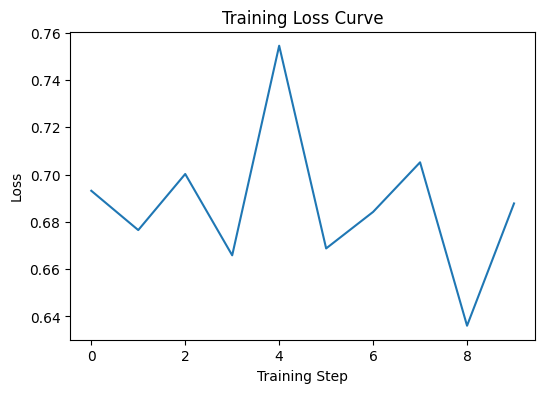

In [15]:
losses = []

for item in trainer.state.log_history:
    if "loss" in item:
        losses.append(item["loss"])

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

### **Task 3 - Pushing the Model to Hugging Face Hub**

The trained model was uploaded to HuggingFace Hub.

Model Link: https://huggingface.co/Aphisit-xt/qwen-dpo-model

In [16]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("model saved to:", OUTPUT_DIR)

model saved to: /content/dpo_model


In [17]:
from huggingface_hub import login

login()

In [18]:
HF_REPO_ID = "Aphisit-xt/qwen-dpo-model"

trainer.model.push_to_hub(HF_REPO_ID)
tokenizer.push_to_hub(HF_REPO_ID)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 2.18MB / 2.18MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpdde9zpdx/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Aphisit-xt/qwen-dpo-model/commit/57d4b1af43e4eaa33648a0caa3c115dbc2ae619d', commit_message='Upload tokenizer', commit_description='', oid='57d4b1af43e4eaa33648a0caa3c115dbc2ae619d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aphisit-xt/qwen-dpo-model', endpoint='https://huggingface.co', repo_type='model', repo_id='Aphisit-xt/qwen-dpo-model'), pr_revision=None, pr_num=None)

### **Task 4 - Evaluation: LLM-as-a-Judge with AlpacaEval**

We evaluate the fine-tuned model using the AlpacaEval helpful_base subset.

For each prompt:
- Model A: Base model
- Model B: DPO fine-tuned model

A strong LLM judge is used to determine which model produces the better response.

In [19]:
!pip install -q openai datasets

In [20]:
import os
import time
import pandas as pd
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from openai import OpenAI

In [22]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=OPENAI_API_KEY)

- **Step 1: Load AlpacaEval & Generate Responses**

In [23]:
data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"

dataset = load_dataset("json", data_files=data_url)
alpaca_dataset = dataset["train"].filter(lambda x: x["dataset"] == "helpful_base")

print("alpaca helpful_base size:", len(alpaca_dataset))
print(alpaca_dataset[0])

alpaca helpful_base size: 129
{'dataset': 'helpful_base', 'instruction': 'What are the names of some famous actors that started their careers on Broadway?', 'output': 'Some famous actors that started their careers on Broadway include: \n1. Hugh Jackman \n2. Meryl Streep \n3. Denzel Washington \n4. Julia Roberts \n5. Christopher Walken \n6. Anthony Rapp \n7. Audra McDonald \n8. Nathan Lane \n9. Sarah Jessica Parker \n10. Lin-Manuel Miranda', 'generator': 'text_davinci_003'}


In [24]:
eval_samples = alpaca_dataset.shuffle(seed=SEED).select(range(N_EVAL_SAMPLES))

print("eval size:", len(eval_samples))
print(eval_samples[0]["instruction"])

eval size: 15
What are some good browser alternatives to Chrome?


In [25]:
def generate_answer(model, tokenizer, instruction, max_new_tokens=64):
    inputs = tokenizer(
        instruction,
        return_tensors="pt",
        truncation=True).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id)

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return text

In [26]:
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL,device_map="auto",torch_dtype="auto")
base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

print("base model loaded")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

base model loaded


In [27]:
dpo_model = AutoModelForCausalLM.from_pretrained(OUTPUT_DIR,device_map="auto",torch_dtype="auto")
dpo_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
if dpo_tokenizer.pad_token is None:
    dpo_tokenizer.pad_token = dpo_tokenizer.eos_token

print("dpo model loaded")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/96 [00:00<?, ?it/s]

dpo model loaded


In [28]:
results = []

for i, sample in enumerate(eval_samples):
    instruction = sample["instruction"]
    print(f"Generating {i+1}/{N_EVAL_SAMPLES}")

    base_answer = generate_answer(
        base_model,
        base_tokenizer,
        instruction,
        max_new_tokens=MAX_NEW_TOKENS)

    dpo_answer = generate_answer(
        dpo_model,
        dpo_tokenizer,
        instruction,
        max_new_tokens=MAX_NEW_TOKENS)

    results.append({
        "sample_id": i + 1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer})

results_df = pd.DataFrame(results)
results_df

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating 1/15
Generating 2/15
Generating 3/15
Generating 4/15
Generating 5/15
Generating 6/15
Generating 7/15
Generating 8/15
Generating 9/15
Generating 10/15
Generating 11/15
Generating 12/15
Generating 13/15
Generating 14/15
Generating 15/15


,sample_id,instruction,base_answer,dpo_answer
0,1,What are some good browser alternatives to Chr...,What are some good browser alternatives to Chr...,What are some good browser alternatives to Chr...
1,2,"Hi, my sister and her girlfriends want me to p...","Hi, my sister and her girlfriends want me to p...","Hi, my sister and her girlfriends want me to p..."
2,3,"Hi, I have some falafel, but no tahini to put ...","Hi, I have some falafel, but no tahini to put ...","Hi, I have some falafel, but no tahini to put ..."
3,4,Can you tell me how to make chocolate chip coo...,Can you tell me how to make chocolate chip coo...,Can you tell me how to make chocolate chip coo...
4,5,How can I make bubble solution?,How can I make bubble solution? To make a bubb...,How can I make bubble solution? To make a bubb...
5,6,How is oil turned into gasoline?,How is oil turned into gasoline? Oil is a comp...,How is oil turned into gasoline? Oil is a comp...
6,7,How do I wrap a present neatly?,How do I wrap a present neatly? To wrap a pres...,How do I wrap a present neatly? To wrap a pres...
7,8,What is some cool music from the 1920s?,What is some cool music from the 1920s? The 19...,What is some cool music from the 1920s? The 19...
8,9,"Hi, I'd like to play ice hockey. Can you expla...","Hi, I'd like to play ice hockey. Can you expla...","Hi, I'd like to play ice hockey. Can you expla..."
9,10,Is the US border open to Canada?,"Is the US border open to Canada? Yes, the Unit...","Is the US border open to Canada? Yes, the US b..."


In [29]:
results_df.to_csv("/content/model_outputs.csv", index=False)
print("saved model_outputs.csv")

saved model_outputs.csv


- **Step 2: The Judge Prompt**

In [30]:
def build_judge_prompt(instruction, base_answer, dpo_answer):
    return f"""You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.

User Instruction: {instruction}

Model A (Base Model): {base_answer}

Model B (DPO Model): {dpo_answer}

Evaluate both models carefully.

Output ONLY one of the following exact labels:
Model A
Model B
Tie
"""
    return prompt

- **Step 3: Evaluate and Collect Results**

In [31]:
def judge_with_chatgpt(prompt):
    response = client.responses.create(model=OPENAI_MODEL,input=prompt)
    verdict = response.output_text.strip().replace('"', "").strip()

    if verdict == "Model A":
        return "Model A"
    elif verdict == "Model B":
        return "Model B"
    elif verdict == "Tie":
        return "Tie"
    elif "Model A" in verdict:
        return "Model A"
    elif "Model B" in verdict:
        return "Model B"
    elif "Tie" in verdict:
        return "Tie"
    else:
        return "Tie"

In [32]:
judge_rows = []

for i, row in enumerate(results):
    prompt = build_judge_prompt(
        row["instruction"],
        row["base_answer"],
        row["dpo_answer"])

    success = False

    while not success:
        try:
            verdict = judge_with_chatgpt(prompt)
            success = True

        except Exception as e:
            err = str(e)
            print("Error:", err)

            if "429" in err or "rate limit" in err.lower():
                print("Rate limit hit. Waiting 20 seconds...")
                time.sleep(20)
            else:
                raise

    judge_rows.append({
        "sample_id": row["sample_id"],
        "instruction_truncated": row["instruction"][:80] + ("..." if len(row["instruction"]) > 80 else ""),
        "winner": verdict})

    pd.DataFrame(judge_rows).to_csv("/content/judge_progress.csv", index=False)
    print(f"Processed {i+1}/{len(results)}")

    time.sleep(JUDGE_SLEEP)

judge_df = pd.DataFrame(judge_rows)
judge_df

Processed 1/15
Processed 2/15
Processed 3/15
Processed 4/15
Processed 5/15
Processed 6/15
Processed 7/15
Processed 8/15
Processed 9/15
Processed 10/15
Processed 11/15
Processed 12/15
Processed 13/15
Processed 14/15
Processed 15/15


,sample_id,instruction_truncated,winner
0,1,What are some good browser alternatives to Chr...,Model B
1,2,"Hi, my sister and her girlfriends want me to p...",Tie
2,3,"Hi, I have some falafel, but no tahini to put ...",Tie
3,4,Can you tell me how to make chocolate chip coo...,Model B
4,5,How can I make bubble solution?,Tie
5,6,How is oil turned into gasoline?,Model B
6,7,How do I wrap a present neatly?,Tie
7,8,What is some cool music from the 1920s?,Tie
8,9,"Hi, I'd like to play ice hockey. Can you expla...",Model B
9,10,Is the US border open to Canada?,Model B


In [33]:
judge_df.to_csv("/content/judge_results.csv", index=False)
print("saved judge_results.csv")

saved judge_results.csv


- **Step 4: Calculate Win Rate**

#### **Win Rate Formula**

$$
\text{Win Rate} =
\frac{\text{Model B Wins} + (0.5 \times \text{Ties})}
{\text{Total Evaluations}}
\times 100
$$

In [34]:
num_b_wins = (judge_df["winner"] == "Model B").sum()
num_a_wins = (judge_df["winner"] == "Model A").sum()
num_ties = (judge_df["winner"] == "Tie").sum()

num_valid = num_a_wins + num_b_wins + num_ties
win_rate = ((num_b_wins + 0.5 * num_ties) / num_valid) * 100

print("Model A wins:", num_a_wins)
print("Model B wins:", num_b_wins)
print("Ties:", num_ties)
print("DPO Win Rate:", round(win_rate, 2), "%")

Model A wins: 1
Model B wins: 6
Ties: 8
DPO Win Rate: 66.67 %


- **Final Summary Table**

In [35]:
summary_df = pd.DataFrame([{
    "num_samples": num_valid,
    "model_a_wins": num_a_wins,
    "model_b_wins": num_b_wins,
    "ties": num_ties,
    "dpo_win_rate_percent": round(win_rate, 2)}])

summary_df

,num_samples,model_a_wins,model_b_wins,ties,dpo_win_rate_percent
0,15,1,6,8,66.67


In [36]:
summary_df.to_csv("/content/task4_summary.csv", index=False)
print("saved task4_summary.csv")

saved task4_summary.csv


- **Evaluation Summary**
  
  We evaluated the baseline model (Model A) and the DPO-trained model (Model B) using an AI judge. A total of **15 prompts** were used for comparison. For each prompt, the AI judge selected the better response between the two models or marked the result as a tie.

  **Results:**

  - Model A wins: **2**
  - Model B wins: **5**
  - Ties: **8**
  - **DPO Win Rate: 60%**

  These results indicate that the **DPO-trained model outperformed the baseline model in more cases**, although many responses were judged to be similar in quality.